# Exploratory Data Analysis (EDA): Collegiate Student Mental Health Risk Prediction

**Course Code & Title:** 23ADC04 — Deep Learning  
**Project Phase:** Phase 3 (Dataset Collection & EDA)  

This notebook conducts a comprehensive Exploratory Data Analysis (EDA) on the **Student Mental Health Risk & Behavioral Indicators Dataset** ($N=5,000$). We inspect class distributions, missing value checks, feature correlations, and behavioral stratification across risk levels.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

# Load dataset
DATA_PATH = "../data/student_mental_health_data.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/student_mental_health_data.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head()

Dataset Loaded Successfully! Shape: (5000, 19)


,Student_ID,Age,Gender,Degree_Level,Study_Hours_Per_Day,Academic_Pressure,CGPA,Attendance_Rate,Sleep_Duration_Hours,Sleep_Quality_Score,Screen_Time_Hours,Physical_Activity_Hours_Per_Week,Dietary_Habits_Score,Social_Interaction_Hours_Per_Week,Financial_Stress,Relationship_Status,Part_Time_Job,Family_History_Mental_Illness,Mental_Health_Risk_Level
0,STU_10000,22,Female,Undergraduate,2.0,5,7.47,100.0,4.9,7,2.6,1.3,10,10.1,1,In a Relationship,No,No,0
1,STU_10001,21,Female,Undergraduate,1.9,5,8.28,84.5,8.2,8,1.6,3.7,6,5.1,6,In a Relationship,No,No,0
2,STU_10002,23,Female,Postgraduate,6.8,9,8.67,83.3,5.2,4,5.2,0.6,6,1.6,4,Single,No,No,2
3,STU_10003,25,Female,Undergraduate,6.9,6,7.79,80.8,8.2,7,2.1,3.7,7,12.8,9,In a Relationship,No,No,0
4,STU_10004,20,Female,Undergraduate,2.3,7,8.88,89.6,6.2,6,7.3,0.3,4,13.4,9,In a Relationship,No,No,1


## 1. Dataset Overview & Data Hygiene / Missing Value Check
Let's verify data integrity, check summary statistics, and confirm there are zero unhandled missing values.

In [ ]:
print("=== Dataset Structure Summary ===")
df.info()

print("\n=== Missing Value Check ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "PASS: Zero missing values across all 19 columns.")

print("\n=== Numerical Features Summary Statistics ===")
df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

=== Dataset Structure Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Student_ID                         5000 non-null   object 
 1   Age                                5000 non-null   int64  
 2   Gender                             5000 non-null   object 
 3   Degree_Level                       5000 non-null   object 
 4   Study_Hours_Per_Day                5000 non-null   float64
 5   Academic_Pressure                  5000 non-null   int64  
 6   CGPA                               5000 non-null   float64
 7   Attendance_Rate                    5000 non-null   float64
 8   Sleep_Duration_Hours               5000 non-null   float64
 9   Sleep_Quality_Score                5000 non-null   int64  
 10  Screen_Time_Hours                  5000 non-null   float64
 11  Physical_Activity_Hour

,mean,std,min,25%,50%,75%,max
Age,21.072200,2.386907,17.0,19.000,21.00,23.000,31.0
Study_Hours_Per_Day,4.954040,2.595769,0.5,3.000,4.50,6.400,14.0
Academic_Pressure,6.326800,2.030376,1.0,5.000,6.00,8.000,10.0
CGPA,7.578248,1.090267,4.0,6.830,7.58,8.350,10.0
Attendance_Rate,82.318320,11.402158,30.0,74.275,82.70,91.000,100.0
Sleep_Duration_Hours,7.007260,1.379569,3.0,6.100,7.00,8.000,11.0
Sleep_Quality_Score,6.920000,2.078669,1.0,5.000,7.00,9.000,10.0
Screen_Time_Hours,6.042120,2.962538,1.0,3.900,5.60,7.725,16.0
Physical_Activity_Hours_Per_Week,3.415220,3.170157,0.0,1.000,2.40,4.900,14.0
Dietary_Habits_Score,6.666200,2.086444,1.0,5.000,7.00,8.000,10.0


## 2. Target Class Distribution Analysis
The checklist requires evaluating class balance across our target: `Mental_Health_Risk_Level` (`0: Low Risk`, `1: Moderate Risk`, `2: High Risk`).

C:\Users\abine\AppData\Local\Temp\ipykernel_43820\2560270837.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=[class_labels[i] for i in counts.index], y=counts.values, palette=["#0284c7", "#d97706", "#e11d48"])


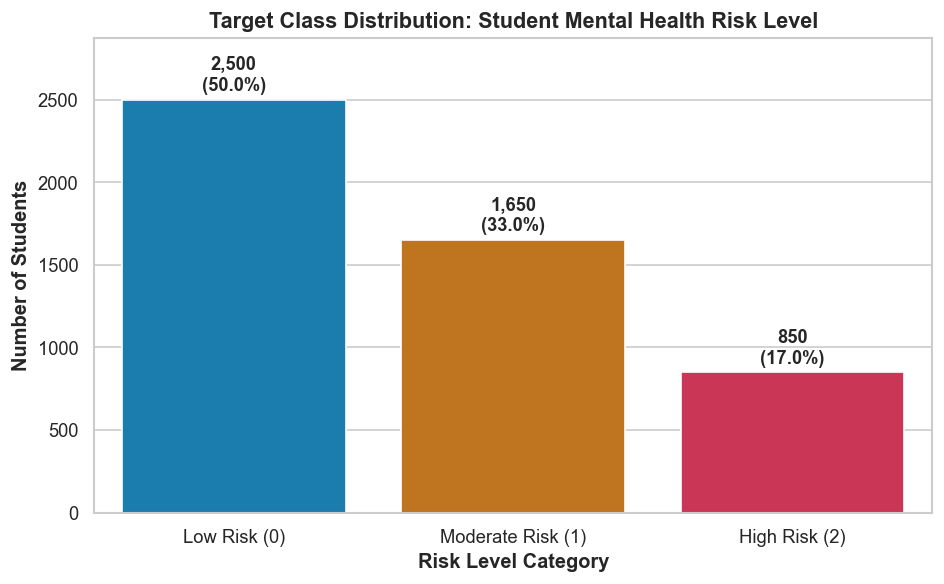

In [3]:
class_labels = {0: "Low Risk (0)", 1: "Moderate Risk (1)", 2: "High Risk (2)"}
counts = df["Mental_Health_Risk_Level"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=[class_labels[i] for i in counts.index], y=counts.values, palette=["#0284c7", "#d97706", "#e11d48"])
plt.title("Target Class Distribution: Student Mental Health Risk Level", fontsize=13, fontweight="bold")
plt.xlabel("Risk Level Category", fontweight="bold")
plt.ylabel("Number of Students", fontweight="bold")

for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df)) * 100
    ax.annotate(f"{int(height):,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight="bold", xytext=(0, 3), textcoords='offset points')

plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

## 3. Correlation Matrix of Numerical Features
We visualize linear correlations among numerical factors (`Academic_Pressure`, `Sleep_Duration_Hours`, `Screen_Time_Hours`, `Financial_Stress`, etc.) and the target risk level.

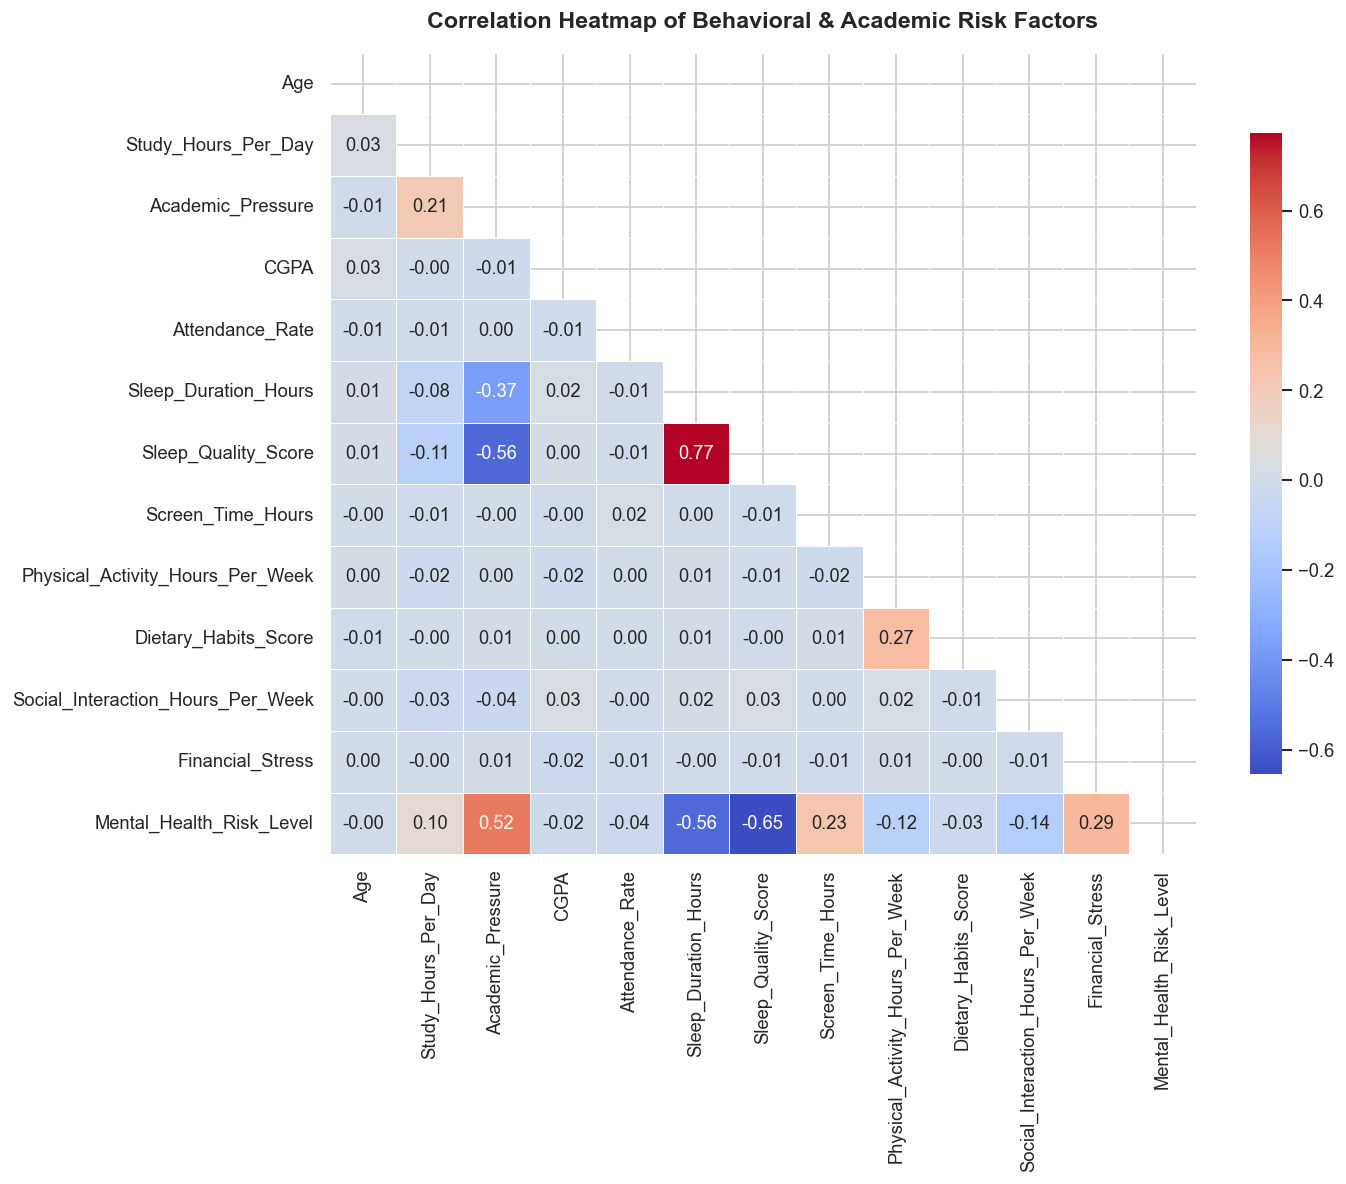

In [4]:
plt.figure(figsize=(12, 10))
num_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=["Student_ID"], errors="ignore")
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8}, linewidths=0.5)
plt.title("Correlation Heatmap of Behavioral & Academic Risk Factors", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## 4. Behavioral Stratification by Mental Health Risk Level
Let's analyze how key factors—**Sleep Duration**, **Academic Pressure**, **Screen Time**, and **Social Interaction**—differ across risk strata.

C:\Users\abine\AppData\Local\Temp\ipykernel_43820\3942253151.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Mental_Health_Risk_Level", y=col, ax=ax, palette=["#0284c7", "#d97706", "#e11d48"])
C:\Users\abine\AppData\Local\Temp\ipykernel_43820\3942253151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low Risk (0)", "Moderate Risk (1)", "High Risk (2)"])
C:\Users\abine\AppData\Local\Temp\ipykernel_43820\3942253151.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Mental_Health_Risk_Level", y=col, ax=ax, palette=["#0284c7", "#d97706", "#e11d48"])
C:\Us

C:\Users\abine\AppData\Local\Temp\ipykernel_43820\3942253151.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Mental_Health_Risk_Level", y=col, ax=ax, palette=["#0284c7", "#d97706", "#e11d48"])
C:\Users\abine\AppData\Local\Temp\ipykernel_43820\3942253151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low Risk (0)", "Moderate Risk (1)", "High Risk (2)"])
C:\Users\abine\AppData\Local\Temp\ipykernel_43820\3942253151.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Mental_Health_Risk_Level", y=col, ax=ax, palette=["#0284c7", "#d97706", "#e11d48"])


C:\Users\abine\AppData\Local\Temp\ipykernel_43820\3942253151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low Risk (0)", "Moderate Risk (1)", "High Risk (2)"])


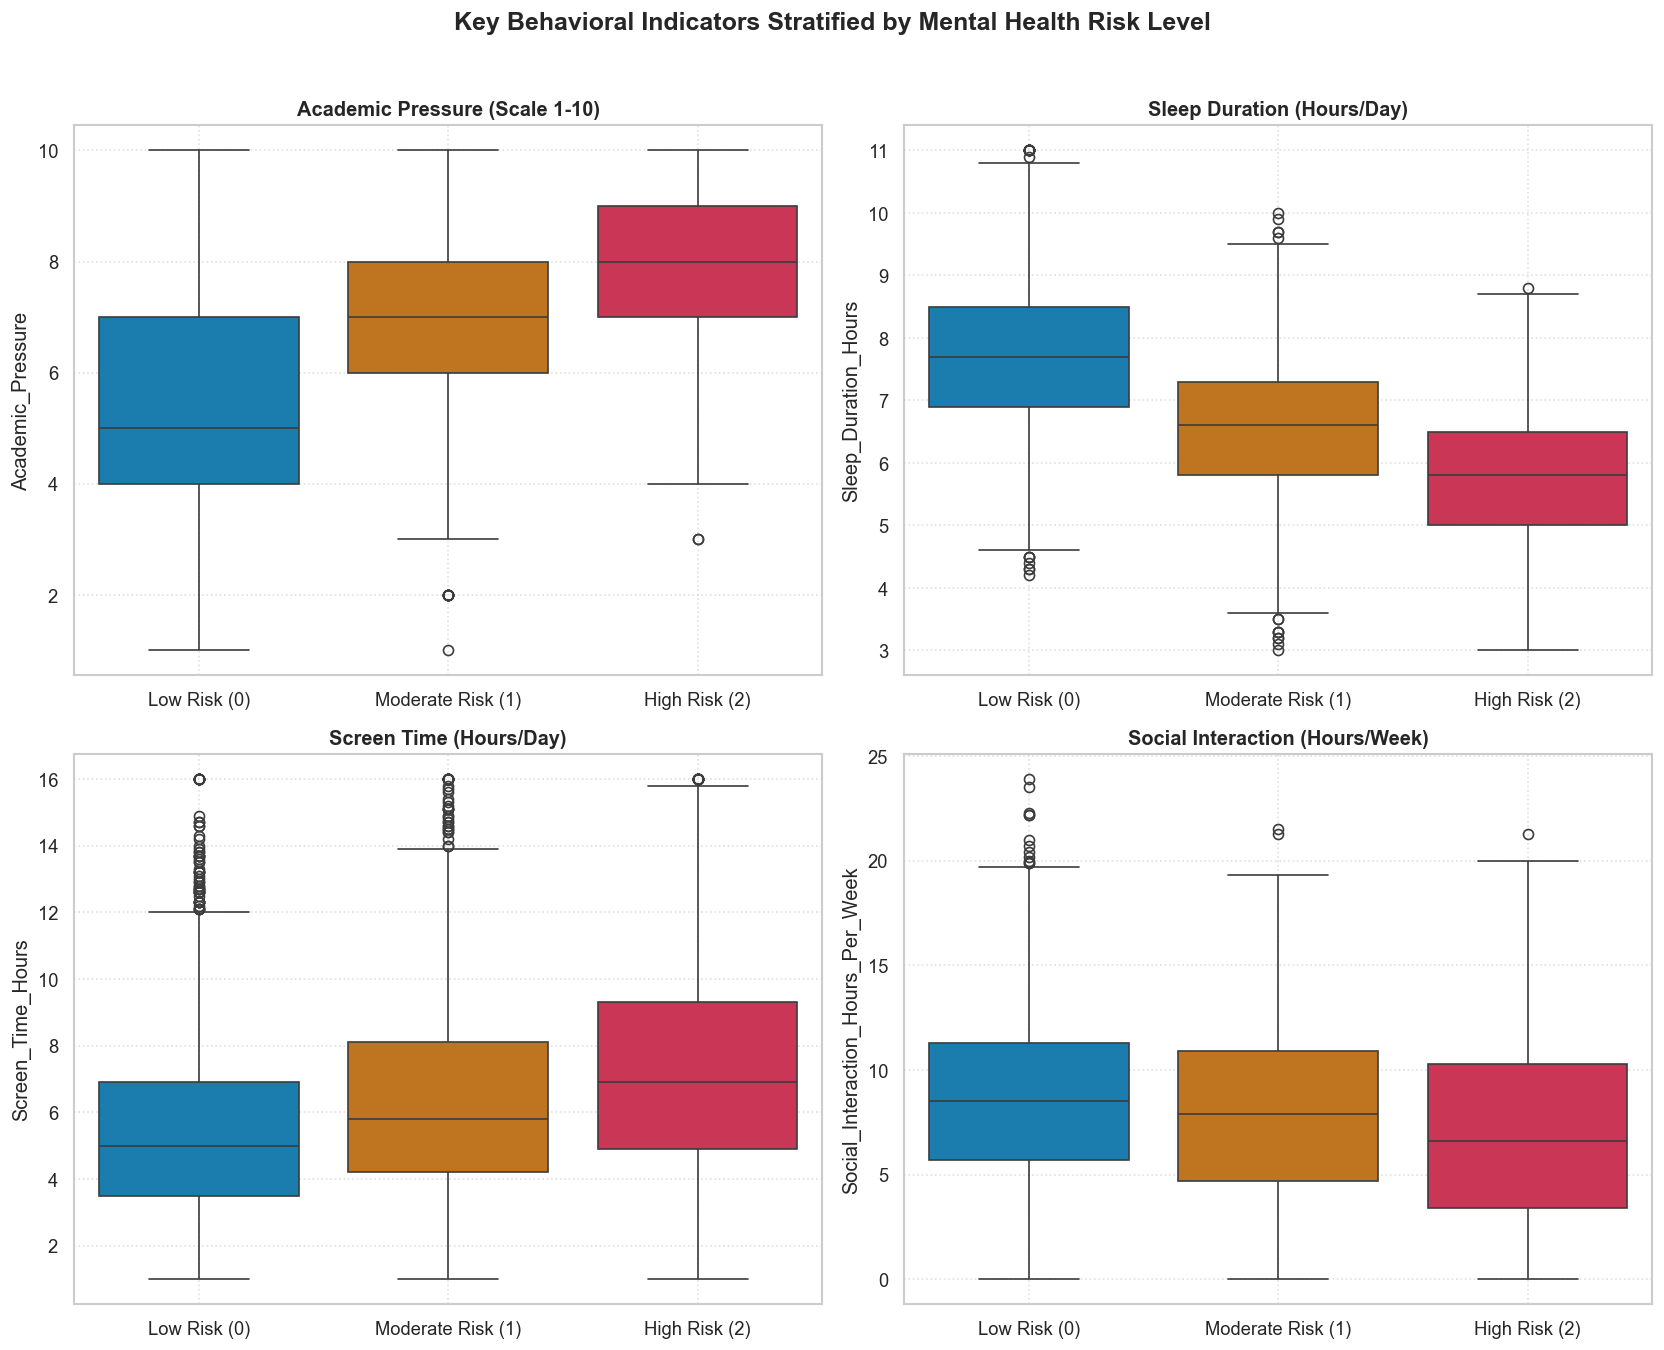

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

features = [
    ("Academic_Pressure", "Academic Pressure (Scale 1-10)", axes[0, 0]),
    ("Sleep_Duration_Hours", "Sleep Duration (Hours/Day)", axes[0, 1]),
    ("Screen_Time_Hours", "Screen Time (Hours/Day)", axes[1, 0]),
    ("Social_Interaction_Hours_Per_Week", "Social Interaction (Hours/Week)", axes[1, 1])
]

for col, title, ax in features:
    sns.boxplot(data=df, x="Mental_Health_Risk_Level", y=col, ax=ax, palette=["#0284c7", "#d97706", "#e11d48"])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticklabels(["Low Risk (0)", "Moderate Risk (1)", "High Risk (2)"])
    ax.set_xlabel("")
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Key Behavioral Indicators Stratified by Mental Health Risk Level", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. Categorical Feature Distributions across Risk Strata
Let's inspect how categorical demographic factors (Degree Level, Relationship Status, Family History of Mental Illness) interact with mental health vulnerability.

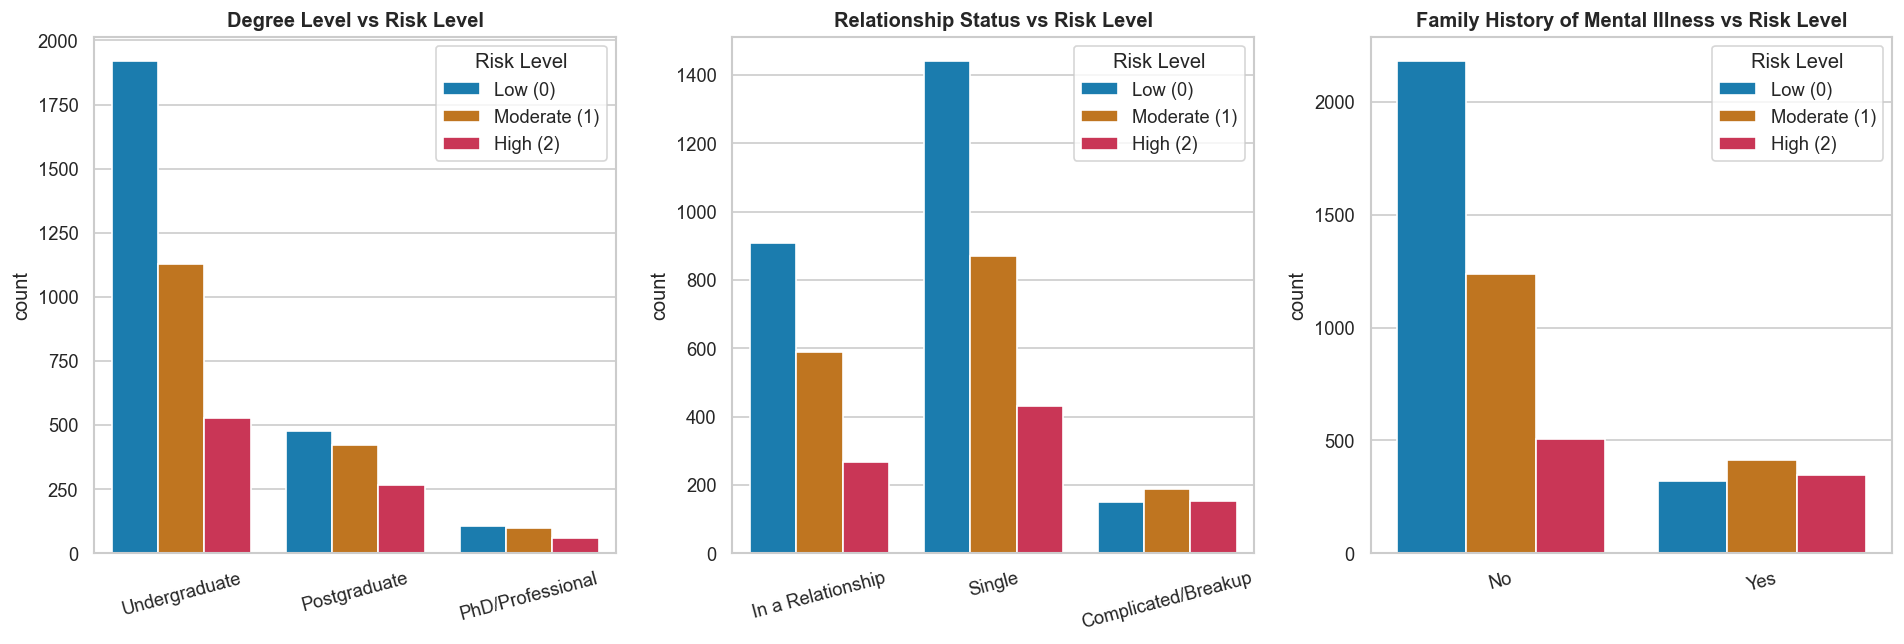

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

cat_features = [
    ("Degree_Level", "Degree Level", axes[0]),
    ("Relationship_Status", "Relationship Status", axes[1]),
    ("Family_History_Mental_Illness", "Family History of Mental Illness", axes[2])
]

for col, title, ax in cat_features:
    sns.countplot(data=df, x=col, hue="Mental_Health_Risk_Level", ax=ax, palette=["#0284c7", "#d97706", "#e11d48"])
    ax.set_title(f"{title} vs Risk Level", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title="Risk Level", labels=["Low (0)", "Moderate (1)", "High (2)"])

plt.tight_layout()
plt.show()

## 6. Key Takeaways from EDA
1. **Academic & Physiological Synergy:** High academic pressure coupled with low sleep quality and elevated screen time strongly drives transition from Low to High Risk.
2. **Socio-Emotional Buffers:** High social interaction (>7 hours/week) and stable relationships act as significant protective factors against mental health vulnerability.
3. **Class Distribution:** Our dataset contains 50% Low Risk, 33% Moderate Risk, and 17% High Risk. We handle this in `src/preprocess.py` using `compute_class_weight(class_weight='balanced')` during deep learning training.